In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

def lowpass_filter(data, cutoff_freq, sampling_rate, filter_order=4):
    normalized_cutoff = cutoff_freq / (sampling_rate / 2)
    # b, a = scipy.signal.butter(filter_order, normalized_cutoff, btype='low', analog=False)
    a = np.array([1, -(1-1/2**filter_order)])
    b = np.array([1/2**filter_order])
    filtered_data = scipy.signal.lfilter(b, a, data)
    return filtered_data

def highpass_filter(data, cutoff_freq, sampling_rate, filter_order=4):
    normalized_cutoff = cutoff_freq / (sampling_rate / 2)
    b, a = scipy.signal.butter(filter_order, normalized_cutoff, btype='high', analog=False)
    filtered_data = scipy.signal.lfilter(b, a, data)
    return filtered_data

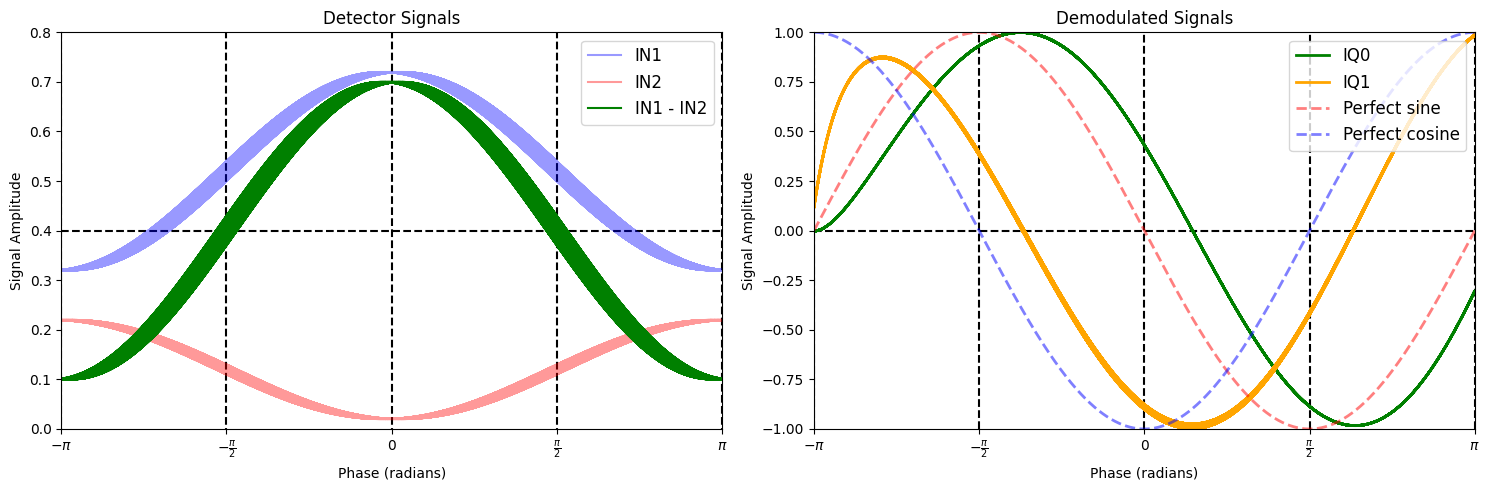

In [4]:
A = 0.52
B = 0.2
C = 0.12
D = 0.1
mod_freq = 1e5
cutoff_freq = 150  # Hz
filter_order = 20
mod_depth = 0.1
time = np.linspace(-1, 1, int(16e6))

phi_setpoint = 3/4*np.pi

w_mod = 2 * np.pi * mod_freq
# phi_bare = 1.2*np.pi*time/time[-1]
phi_bare = 1.2*np.pi*np.sin(time)
phi = phi_bare + mod_depth * np.cos(w_mod*time)
sampling_rate = 1 / (time[1] - time[0])

det_sig1 = A + B * np.cos(phi)
det_sig2 = C - D * np.cos(phi)
diff_sig = det_sig1 - det_sig2
diff_sig_1f_demod = diff_sig * np.cos(w_mod*time)
diff_sig_2f_demod = diff_sig * np.cos(2*w_mod*time)

filtered_demod_diff_sig_1f = lowpass_filter(diff_sig_1f_demod, cutoff_freq, sampling_rate, filter_order)
filtered_demod_diff_sig_2f = lowpass_filter(diff_sig_2f_demod, cutoff_freq, sampling_rate, filter_order)

# second_filtered_diff_sig_1f = highpass_filter(filtered_demod_diff_sig_1f, hpf_cutoff, sampling_rate, hpf_order)
# second_filtered_diff_sig_2f = highpass_filter(filtered_demod_diff_sig_2f, hpf_cutoff, sampling_rate, hpf_order)vxmc

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].vlines(np.arange(-np.pi, np.pi+0.1, np.pi/2), ymin=-1, ymax=1, color='black', linestyle='--', linewidth=1.5)
ax[0].axhline(A - C, color='black', linestyle='--', linewidth=1.5)
ax[0].plot(phi_bare, det_sig1, label='IN1', color='blue', alpha=0.4)
ax[0].plot(phi_bare, det_sig2, label='IN2', color='red', alpha=0.4)
ax[0].plot(phi_bare, diff_sig, label='IN1 - IN2', color='green')
ax[0].set_title('Detector Signals')
ax[0].set_xlabel('Phase (radians)')
ax[0].set_ylabel('Signal Amplitude')
ax[0].set_xlim(-np.pi, np.pi)
ax[0].set_ylim(0, 0.8)
ax[0].legend(fontsize=12, loc='upper right')
ax[0].set_xticks(np.arange(-np.pi, np.pi+0.1, np.pi/2), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])

ax[1].vlines(np.arange(-np.pi, np.pi+0.1, np.pi/2), ymin=-1, ymax=1, color='black', linestyle='--', linewidth=1.5)
ax[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
ax[1].plot(phi_bare, filtered_demod_diff_sig_1f / np.max(filtered_demod_diff_sig_1f), label='IQ0', color='green', lw=2)
ax[1].plot(phi_bare, filtered_demod_diff_sig_2f / np.max(filtered_demod_diff_sig_2f), label='IQ1', color='orange', lw=2)
ax[1].plot(phi_bare, -np.sin(phi_bare), label='Perfect sine', color='red', lw=2, ls="--", alpha=0.5)
ax[1].plot(phi_bare, -np.cos(phi_bare), label='Perfect cosine', color='blue', lw=2, ls="--", alpha=0.5)
# ax[1].plot(phi_bare, np.cos(phi_setpoint) * filtered_demod_diff_sig_1f / np.max(filtered_demod_diff_sig_1f) - np.sin(phi_setpoint) * filtered_demod_diff_sig_2f / np.max(filtered_demod_diff_sig_2f), label='Demodulated Signal', color='purple', lw=2)
# ax[1].axvline(phi_setpoint, color='green', linestyle='--', linewidth=1.5, label='Setpoint Phase')
ax[1].set_title('Demodulated Signals')
ax[1].set_xlabel('Phase (radians)')
ax[1].set_ylabel('Signal Amplitude')
ax[1].set_xlim(0, np.pi)
ax[1].set_ylim(-1, 1)
ax[1].legend(fontsize=12, loc='upper right')
ax[1].set_xticks(np.arange(-np.pi, 1.5*np.pi, np.pi/2), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()

C:\Users\berni\AppData\Local\Temp\ipykernel_41604\2254224885.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(phases, 1/2 + 1/2*np.cos(phases), 'ro', markersize=12, label='Measurement points', c="r")


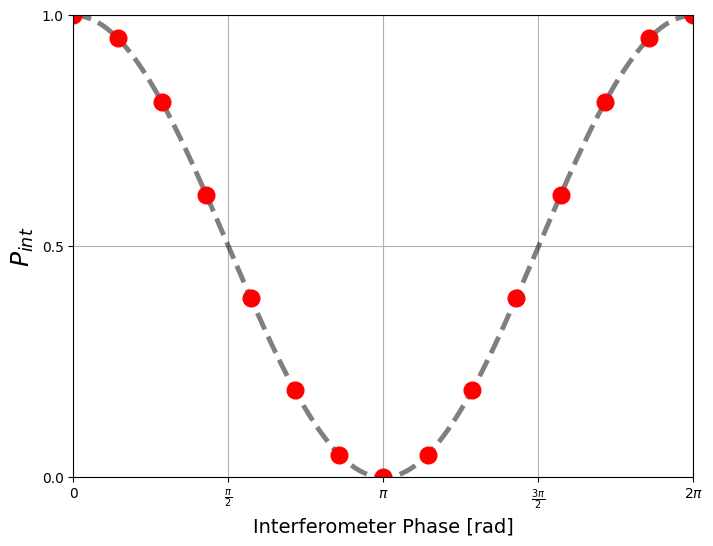

In [35]:
phases = np.linspace(0, 2*np.pi, 15)
phases_fit = np.linspace(0, 2*np.pi, 10000)
plt.figure(figsize=(8, 6))
plt.plot(phases_fit, 1/2 + 1/2*np.cos(phases_fit), c="k", lw=3.5, ls="--", alpha=0.5)
plt.plot(phases, 1/2 + 1/2*np.cos(phases), 'ro', markersize=12, label='Measurement points', c="r")
plt.xlim(0, 2*np.pi)
# plt.ylim(-0.01, 1.01)
plt.ylim(0, 1)
plt.xticks(
    np.arange(0, 2*np.pi + 0.1, np.pi/2), 
    labels=[r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
)
plt.yticks([0, 0.5, 1])
plt.xlabel("Interferometer Phase [rad]", fontsize=14)
plt.ylabel(r"$P_{int}$", fontsize=18)
plt.grid()
# plt.legend()
plt.show()

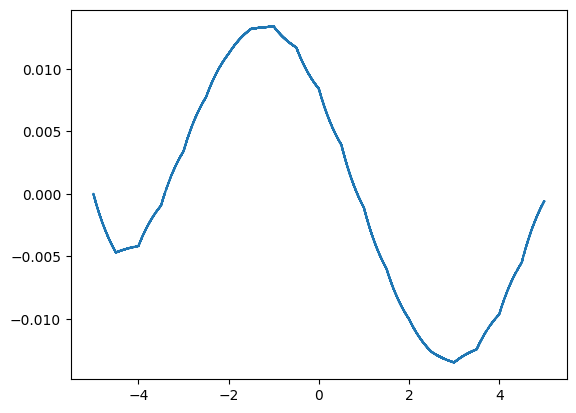

In [28]:
# plt.plot(time, det_sig1)
plt.plot(time, filtered_demod_diff_sig_1f)

In [32]:
err_signal = np.cos(phi_setpoint) * 4.15*8*filtered_demod_diff_sig_1f - np.sin(phi_setpoint) * 4/3*500*filtered_demod_diff_sig_2f
phi_err = np.abs(phi_setpoint - phi_bare[phi_bare>0][np.argmin(np.abs(err_signal[phi_bare>0]))])
print(f"Error in phase setpoint: {phi_err/np.pi:.4f} π")

Error in phase setpoint: 0.0171 π


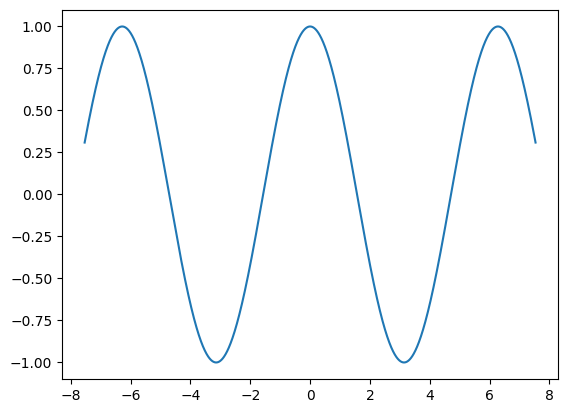

In [71]:
plt.plot(phi_bare, np.cos(phi_bare))

In [70]:
phi_bare

array([-7.53982237, -7.53980729, -7.53979221, ...,  7.53979221,
        7.53980729,  7.53982237])

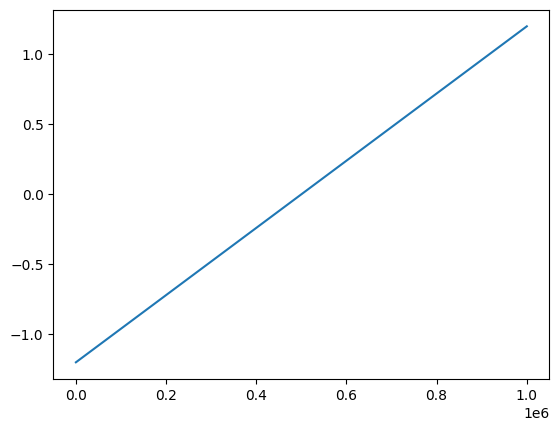

In [69]:
plt.plot(phi_bare/(2*np.pi))

In [38]:
filtered_demod_diff_sig_1f

array([1.51495840e-18, 1.66613548e-17, 9.23739746e-17, ...,
       1.96660751e+61, 1.96699259e+61, 1.96737775e+61])

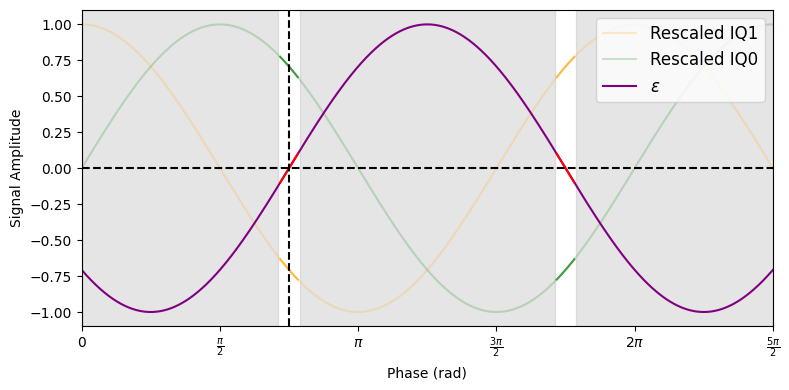

In [5]:
phi_setpoint = 3*np.pi/4

amp_1f = (np.max(filtered_demod_diff_sig_1f[np.logical_and(phi_bare>0, phi_bare<2.5*np.pi)]) - np.min(filtered_demod_diff_sig_1f[np.logical_and(phi_bare>0, phi_bare<2.5*np.pi)]))/2
amp_2f = (np.max(filtered_demod_diff_sig_2f[np.logical_and(phi_bare>0, phi_bare<2.5*np.pi)]) - np.min(filtered_demod_diff_sig_2f[np.logical_and(phi_bare>0, phi_bare<2.5*np.pi)]))/2

unit_sine_sigal = filtered_demod_diff_sig_1f / amp_1f
unit_cosine_signal = filtered_demod_diff_sig_2f / amp_2f

err_signal = np.cos(phi_setpoint) * unit_sine_sigal - np.sin(phi_setpoint) * unit_cosine_signal

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi_bare, unit_cosine_signal, label='Rescaled IQ1', color='orange', alpha=0.2)
ax.plot(phi_bare, unit_sine_sigal, label='Rescaled IQ0', color='green', alpha=0.2)
ax.plot(phi_bare, err_signal, label=r'$\epsilon$', color='purple')
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)], err_signal[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)],  color='r')
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)], unit_cosine_signal[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)],  color='orange', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)], unit_sine_sigal[np.logical_and(phi_bare>phi_setpoint-0.1, phi_bare<phi_setpoint+0.1)],  color='green', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)], err_signal[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)],  color='r')
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)], unit_cosine_signal[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)],  color='orange', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)], unit_sine_sigal[np.logical_and(phi_bare>np.pi+phi_setpoint-0.1, phi_bare<np.pi+phi_setpoint+0.1)],  color='green', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(phi_setpoint, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Phase (rad)')
ax.set_ylabel('Signal Amplitude')
ax.set_xlim(0, 2.5*np.pi)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=12, loc='upper right')
ax.set_xticks(np.arange(0, 2.5*np.pi+0.1, np.pi/2), labels=['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', r'$\frac{5\pi}{2}$'])
ax.fill_between([0, phi_setpoint-0.12], -1.1, 1.1, color='gray', alpha=0.2)
ax.fill_between([phi_setpoint+0.12, phi_setpoint+np.pi-0.12], -1.1, 1.1, color='gray', alpha=0.2)
ax.fill_between([phi_setpoint+np.pi+0.12, 2.5*np.pi], -1.1, 1.1, color='gray', alpha=0.2)

plt.tight_layout()

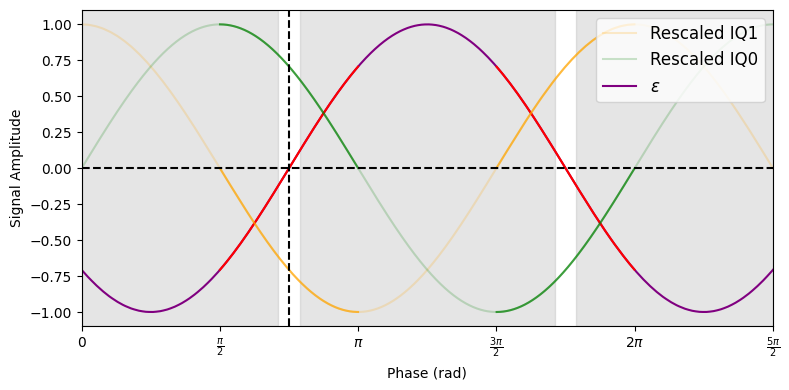

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi_bare, unit_cosine_signal, label='Rescaled IQ1', color='orange', alpha=0.2)
ax.plot(phi_bare, unit_sine_sigal, label='Rescaled IQ0', color='green', alpha=0.2)
ax.plot(phi_bare, err_signal, label=r'$\epsilon$', color='purple')
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)], err_signal[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)],  color='r')
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)], unit_cosine_signal[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)],  color='orange', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)], unit_sine_sigal[np.logical_and(phi_bare>phi_setpoint-np.pi/4, phi_bare<phi_setpoint+np.pi/4)],  color='green', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)], err_signal[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)],  color='r')
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)], unit_cosine_signal[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)],  color='orange', alpha=0.7)
ax.plot(phi_bare[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)], unit_sine_sigal[np.logical_and(phi_bare>np.pi+phi_setpoint-np.pi/4, phi_bare<np.pi+phi_setpoint+np.pi/4)],  color='green', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(phi_setpoint, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Phase (rad)')
ax.set_ylabel('Signal Amplitude')
ax.set_xlim(0, 2.5*np.pi)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=12, loc='upper right')
ax.set_xticks(np.arange(0, 2.5*np.pi+0.1, np.pi/2), labels=['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', r'$\frac{5\pi}{2}$'])
ax.fill_between([0, phi_setpoint-0.12], -1.1, 1.1, color='gray', alpha=0.2)
ax.fill_between([phi_setpoint+0.12, phi_setpoint+np.pi-0.12], -1.1, 1.1, color='gray', alpha=0.2)
ax.fill_between([phi_setpoint+np.pi+0.12, 2.5*np.pi], -1.1, 1.1, color='gray', alpha=0.2)

plt.tight_layout()